# 06 – Modelagem Preditiva (ML)
Treinamento, comparação de modelos, Stacking Ensemble e Interpretabilidade (SHAP).

## 2. Carregamento da Base e Setup

In [1]:
import os
import sys
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import shap
from pathlib import Path
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_recall_curve, recall_score, precision_score, f1_score, average_precision_score, brier_score_loss
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import chi2_contingency

# Configurações gráficas
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'], 'font.size': 11})
def enforce_tcc_style(): plt.grid(False); plt.gca().spines['top'].set_visible(False); plt.gca().spines['right'].set_visible(False)
FIG_PATH = Path('../reports/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path: sys.path.append(ROOT)


/home/carolina/miniconda3/envs/iam/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = Path('../data/processed/base_modelagem_reduzida.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

df['indicador_obito'] = df['indicador_obito'].astype(int)

#  Split Temporal: treino 2015–2022 · teste 2023–2025 
ANO_CORTE = 2023

df['ano_competencia'] = df['ano_competencia'].astype(str).str[:4]

df_treino = df[df['ano_competencia'] < str(ANO_CORTE)].copy()
df_teste  = df[df['ano_competencia'] >= str(ANO_CORTE)].copy()

print(f'Treino (2015–{ANO_CORTE - 1}): {len(df_treino):,} registros  '
      f'| Óbitos: {df_treino["indicador_obito"].sum():,} '
      f'({df_treino["indicador_obito"].mean()*100:.2f}%)')
print(f'Teste  ({ANO_CORTE}–2025):  {len(df_teste):,} registros  '
      f'| Óbitos: {df_teste["indicador_obito"].sum():,} '
      f'({df_teste["indicador_obito"].mean()*100:.2f}%)')

# Encoding e separação X / y 
col_ano = 'ano_competencia'

X_treino_raw = df_treino.drop(columns=['indicador_obito', col_ano, 'mes_competencia', 'competencia', 'data_internacao', 'codigo_cnes', 'uti_mes_total_cod', 'diarias_acompanhante', 'quantidade_diarias', 'valor_servicos_hospitalares', 'valor_servicos_profissionais', 'valor_total', 'valor_uti', 'valor_total_dolar', 'dias_permanencia_cod', 'tipo_uti', 'diarias', 'custo'], errors='ignore')
y_train      = df_treino['indicador_obito']

X_teste_raw  = df_teste.drop(columns=['indicador_obito', col_ano, 'mes_competencia', 'competencia', 'data_internacao', 'codigo_cnes', 'uti_mes_total_cod', 'diarias_acompanhante', 'quantidade_diarias', 'valor_servicos_hospitalares', 'valor_servicos_profissionais', 'valor_total', 'valor_uti', 'valor_total_dolar', 'dias_permanencia_cod', 'tipo_uti', 'diarias', 'custo'], errors='ignore')
y_test       = df_teste['indicador_obito']

cat_cols = X_treino_raw.select_dtypes(include=['object', 'category']).columns.tolist()
X_train = pd.get_dummies(X_treino_raw, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_teste_raw,  columns=cat_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

clean = lambda cols: [re.sub(r'[\[\]<>\s]', '_', c) for c in cols]
X_train.columns = clean(X_train.columns)
X_test.columns  = clean(X_test.columns)


# =======================================================
# ESTÉTICA SHAP: Renomeando colunas para a tese
# =======================================================
rename_shap = {
    'escore_fragilidade': 'Escore de Fragilidade Clínica',
    'complexidade_cod': 'Complexidade do Procedimento',
    'Complexidade_Procedimento': 'Complexidade do Procedimento',
    'idade': 'Idade do Paciente (Anos)',
    'volume_hospitalar_anual': 'Volume Hospitalar Anual',
    'sexo_Masculino': 'Sexo - Masculino',
    'sexo_Masc': 'Sexo - Masculino',
    'sexo_M': 'Sexo - Masculino',
    'habilitacao_1101': 'Hab. de Assistência em Urgência',
    'hab_UTI_Especializada_1101': 'Hab. UTI Especializada',
    'carater_internacao_Urgência': 'Internação de Urgência',
    'carater_internacao_Urgência_motivo_autorização': 'Internação de Urgência',
    'carater_internacao_Urgencia_motivo_autorização': 'Internação de Urgência',
    'Carater_Internacao_Urgência_motivo_autorização': 'Internação de Urgência',
    'especialidade_leito_cod': 'Especialidade do Leito Clínico',
    'Especialidade_Leito_Clinico': 'Especialidade do Leito Clínico',
    'tipo_diag_sec_1_nan': 'Sem Comorbidade Secundária',
    'tipo_diag_sec_1_NaN': 'Sem Comorbidade Secundária',
    'Comorbidade_1_Nenhuma': 'Sem Comorbidade Secundária',
    'Comorbidade_2_Nenhuma': 'Sem Comorbidade Secundária',
    'Comorbidade_1_Preexistente': 'Comorbidade Pré-existente',
    'tipo_diag_sec_1_PREEXISTENTE': 'Comorbidade Pré-existente',
}

def embelezar_colunas(cols):
    new_cols = []
    for c in cols:
        if c in rename_shap:
            new_cols.append(rename_shap[c])
        elif c.startswith('Comorbidade_'):
            new_cols.append(c.replace('Comorbidade_1_', 'Comorbidade 1 - ')
                             .replace('Comorbidade_2_', 'Comorbidade 2 - ')
                             .replace('Comorbidade_3_', 'Comorbidade 3 - ')
                             .replace('Comorbidade_4_', 'Comorbidade 4 - '))
        elif c.startswith('tipo_diag_sec_1_'):
            new_cols.append(c.replace('tipo_diag_sec_1_', 'Comorbidade 1 - '))
        elif c.startswith('tipo_diag_sec_2_cod_'):
            new_cols.append(c.replace('tipo_diag_sec_2_cod_', 'Comorbidade 2 - '))
        elif c.startswith('tipo_diag_sec_3_cod_'):
            new_cols.append(c.replace('tipo_diag_sec_3_cod_', 'Comorbidade 3 - '))
        elif c.startswith('tipo_gestor_'):
            new_cols.append(c.replace('tipo_gestor_', 'Gestão - '))
        elif c.startswith('Tipo_Gestao_'):
            new_cols.append(c.replace('Tipo_Gestao_', 'Gestão - '))
        else:
            new_cols.append(c)
    return new_cols


X_train.columns = embelezar_colunas(X_train.columns)
X_test.columns = embelezar_colunas(X_test.columns)

print(f'\nShape treino: {X_train.shape}')

print(f'Shape teste:  {X_test.shape}')


Treino (2015–2022): 277,487 registros  | Óbitos: 27,916 (10.06%)
Teste  (2023–2025):  137,880 registros  | Óbitos: 11,041 (8.01%)

Shape treino: (277487, 384)
Shape teste:  (137880, 384)


In [3]:
# LIMIAR_CORR = 0.03 (REMOVIDO!)
# Modelos baseados em árvore (XGBoost, LightGBM, Random Forest) capturam relações não-lineares.
# Um corte de correlação linear (Pearson) poderia jogar fora variáveis cruciais que interagem entre si.
# Além disso, algoritmos com regularização L1/L2 e seleção por Gini lidam muito bem com dimensionalidade alta.

print(f'Nenhum corte de correlação aplicado.')
print(f'Shape treino (Todas as features): {X_train.shape}')
print(f'Shape teste (Todas as features):  {X_test.shape}')
print()
print('Imputação (mediana) e StandardScaler serão ajustados')
print('exclusivamente no treino via Pipeline.fit(X_train, y_train).')


Nenhum corte de correlação aplicado.
Shape treino (Todas as features): (277487, 384)
Shape teste (Todas as features):  (137880, 384)

Imputação (mediana) e StandardScaler serão ajustados
exclusivamente no treino via Pipeline.fit(X_train, y_train).


## 3. Treinamento de Modelos (Base e XGBoost Campeão)


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_recall_curve
import numpy as np

# Peso para desbalanceamento (mantido conforme ajuste da Carolina)
scale_weight = float(np.sqrt(376410 / 38957))

# 1. Logistic Regression (Requer Imputação e Escalonamento)
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# 2. Random Forest (Requer Imputação)
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                  class_weight='balanced', random_state=42, n_jobs=-1))
])

# 3. XGBoost Base (Hiperparâmetros otimizados)
xgb_model = XGBClassifier(
    device='cuda', tree_method='hist', n_estimators=1000, max_depth=7, 
    learning_rate=0.02, min_child_weight=12, colsample_bytree=0.5, subsample=0.8,
    scale_pos_weight=scale_weight, reg_alpha=1.0, reg_lambda=15.0, random_state=42
)

# 4. LightGBM Base
lgb_model = LGBMClassifier(
    n_estimators=1000, max_depth=10, learning_rate=0.02, num_leaves=63,
    class_weight='balanced', random_state=42, verbose=-1
)

#============================================================
# EXECUÇÃO DO TREINAMENTO
#============================================================

print("Treinando Logistic Regression...")
lr_pipeline.fit(X_train, y_train)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_lr = lr_pipeline.predict(X_test)

print("Treinando Random Forest...")
rf_pipeline.fit(X_train, y_train)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred_rf = rf_pipeline.predict(X_test)

print("Treinando LightGBM...")
lgb_model.fit(X_train, y_train)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
y_pred_lgb = lgb_model.predict(X_test)

print("Treinando XGBoost Base...")
xgb_model.fit(X_train, y_train)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

# Define as predições globais como o XGBoost Base (Campeão!)
y_prob = y_prob_xgb
y_pred = y_pred_xgb


Treinando Logistic Regression...
Treinando Random Forest...
Treinando LightGBM...
Treinando XGBoost Base...


/home/carolina/miniconda3/envs/iam/lib/python3.11/site-packages/xgboost/core.py:751: UserWarning: [16:40:36] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

print("=== Validação Cruzada Estratificada (5-Folds) no Treino ===")

# O cross_val_score fará 5 treinamentos/testes independentes dentro dos anos de 2015-2022
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc',
    n_jobs=1
)

print(f"Scores das 5 vias: {np.round(cv_scores, 4)}")
print(f"AUC-ROC Média (CV): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("Isso confirma que a métrica do teste out-of-time (0.8007) não é sorte,")
print("pois a performance média na validação do treino histórico foi altamente estável.")


=== Validação Cruzada Estratificada (5-Folds) no Treino ===
Scores das 5 vias: [0.8208 0.8198 0.8156 0.8216 0.8185]
AUC-ROC Média (CV): 0.8192 (+/- 0.0042)
Isso confirma que a métrica do teste out-of-time (0.8007) não é sorte,
pois a performance média na validação do treino histórico foi altamente estável.


## 4. Avaliação Comparativa (Métricas e Gráficos)

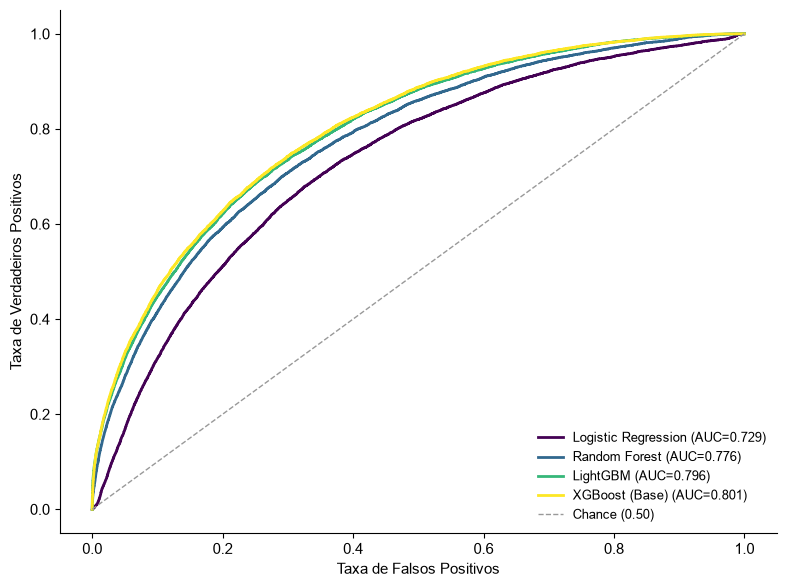

Figura salva: roc_curves_comparativo.jpg


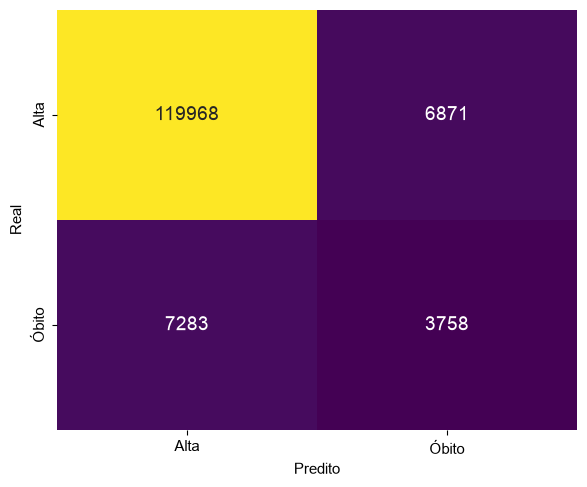

Figura salva: confusion_matrix_xgb_campeao.jpg

=== RESUMO COMPARATIVO — MÉTRICAS DE TESTE (OUT-OF-TIME) ===
Modelo                AUC Teste   PR-AUC   Brier   Recall  Precision     F1
--------------------------------------------------------------------------------
Logistic Regression      0.7293   0.1727  0.2139   66.86%     15.49%  0.252
Random Forest            0.7758   0.2762  0.1833   66.67%     18.11%  0.285
LightGBM                 0.7961   0.3275  0.1560   66.36%     19.92%  0.306
XGBoost (Base)           0.8007   0.3282  0.0854   34.04%     35.36%  0.347


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.metrics import average_precision_score, brier_score_loss
import seaborn as sns

_vir = plt.cm.viridis

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

modelos_roc = [
    ('Logistic Regression', y_test, y_prob_lr),
    ('Random Forest',       y_test, y_prob_rf),
    ('LightGBM',            y_test, y_prob_lgb),
    ('XGBoost (Base)',      y_test, y_prob_xgb),
]
cores_roc = [_vir(i / 3) for i in range(4)]

for (nome, yt, yp), cor in zip(modelos_roc, cores_roc):
    auc  = roc_auc_score(yt, yp)
    fpr, tpr, _ = roc_curve(yt, yp)
    ax_roc.plot(fpr, tpr, color=cor, linewidth=2,
                label=f'{nome} (AUC={auc:.3f})')

ax_roc.plot([0, 1], [0, 1], linestyle='--', color='#999999', linewidth=1,
            label='Chance (0.50)')
ax_roc.set_xlabel('Taxa de Falsos Positivos')
ax_roc.set_ylabel('Taxa de Verdadeiros Positivos')
ax_roc.set_title('')
ax_roc.legend(loc='lower right', frameon=False, fontsize=9)

try:
    enforce_tcc_style()
except:
    pass

ax_roc.grid(False)

plt.tight_layout()
plt.savefig(FIG_PATH / 'roc_curves_comparativo.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: roc_curves_comparativo.jpg')


fig_cm, ax_cm = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=ax_cm, cbar=False,
            annot_kws={'size': 14})

ax_cm.set_title('')
ax_cm.set_xlabel('Predito')
ax_cm.set_ylabel('Real')
ax_cm.set_xticklabels(['Alta', 'Óbito'])
ax_cm.set_yticklabels(['Alta', 'Óbito'])

plt.tight_layout()
plt.savefig(FIG_PATH / 'confusion_matrix_xgb_campeao.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: confusion_matrix_xgb_campeao.jpg')


print('\n=== RESUMO COMPARATIVO — MÉTRICAS DE TESTE (OUT-OF-TIME) ===')
print(f"{'Modelo':<20} {'AUC Teste':>10} {'PR-AUC':>8} {'Brier':>7} {'Recall':>8} {'Precision':>10} {'F1':>6}")
print('-' * 80)
for nome, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr,  y_prob_lr),
    ('Random Forest',       y_pred_rf,  y_prob_rf),
    ('LightGBM',            y_pred_lgb, y_prob_lgb),
    ('XGBoost (Base)',      y_pred_xgb, y_prob_xgb),
]:
    auc_t  = roc_auc_score(y_test, y_prob)
    rec    = recall_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred, zero_division=0)
    f1     = f1_score(y_test, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_test, y_prob)
    brier  = brier_score_loss(y_test, y_prob)
    print(f'{nome:<20} {auc_t:>10.4f} {pr_auc:>8.4f} {brier:>7.4f} {rec:>8.2%} {prec:>10.2%} {f1:>6.3f}')


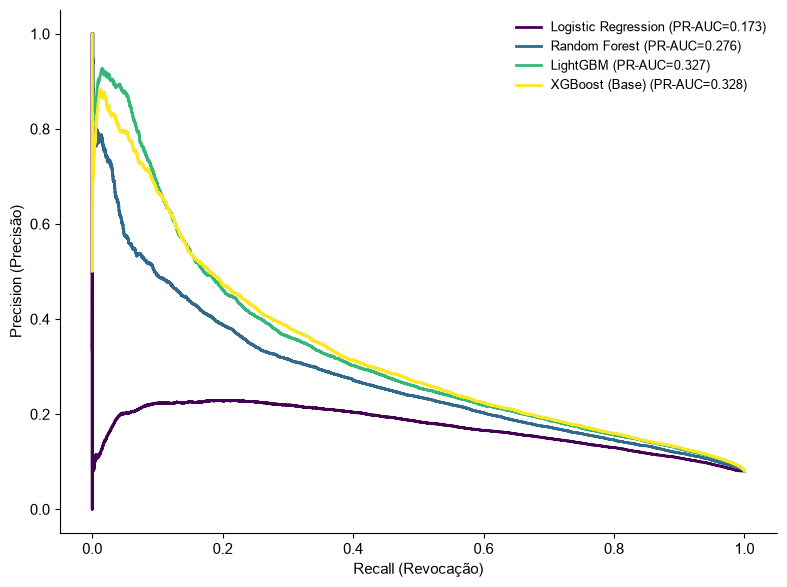

Figura salva: pr_curve_comparativo.jpg


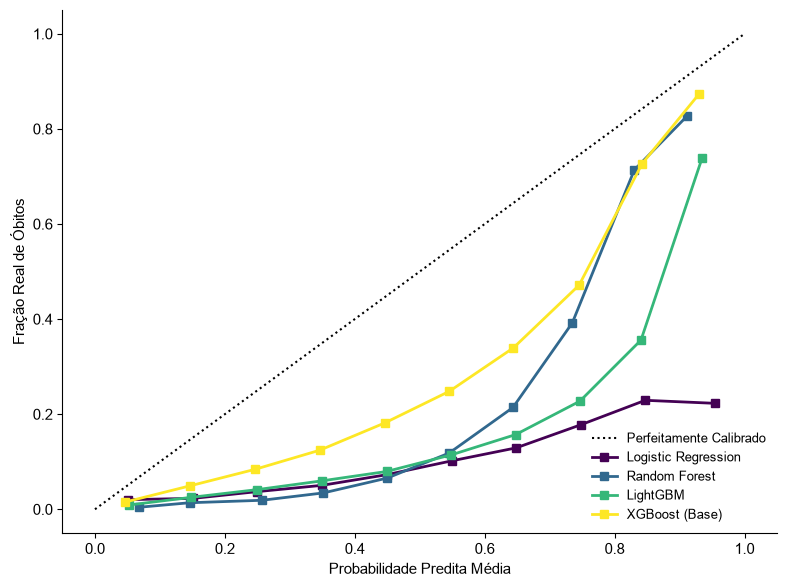

Figura salva: calibration_curve_comparativo.jpg


In [8]:
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve

# ── 4. Curva Precision-Recall (Especial para Desbalanceamento) ────────────────
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))
for (nome, yt, yp), cor in zip(modelos_roc, cores_roc):
    prec, rec, _ = precision_recall_curve(yt, yp)
    pr_auc = average_precision_score(yt, yp)
    ax_pr.plot(rec, prec, color=cor, linewidth=2, label=f'{nome} (PR-AUC={pr_auc:.3f})')

ax_pr.set_xlabel('Recall (Revocação)')
ax_pr.set_ylabel('Precision (Precisão)')
ax_pr.legend(loc='upper right', frameon=False, fontsize=9)
ax_pr.grid(False)
ax_pr.spines['top'].set_visible(False)
ax_pr.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_PATH / 'pr_curve_comparativo.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: pr_curve_comparativo.jpg')

# ── 5. Curva de Calibração (Brier Score Visual) ───────────────────────────────
fig_cal, ax_cal = plt.subplots(figsize=(8, 6))
ax_cal.plot([0, 1], [0, 1], "k:", label="Perfeitamente Calibrado")

for (nome, yt, yp), cor in zip(modelos_roc, cores_roc):
    prob_true, prob_pred = calibration_curve(yt, yp, n_bins=10)
    ax_cal.plot(prob_pred, prob_true, "s-", color=cor, linewidth=2, label=nome)

ax_cal.set_xlabel('Probabilidade Predita Média')
ax_cal.set_ylabel('Fração Real de Óbitos')
ax_cal.legend(loc='lower right', frameon=False, fontsize=9)
ax_cal.grid(False)
ax_cal.spines['top'].set_visible(False)
ax_cal.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_PATH / 'calibration_curve_comparativo.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: calibration_curve_comparativo.jpg')


### 4.1 Significância Estatística (Teste de DeLong)

In [9]:
from scipy import stats
import numpy as np

def delong_roc_test(y_true, y_prob_a, y_prob_b):
    n1 = y_true.sum()
    n0 = len(y_true) - n1
    order = np.argsort(-y_prob_a)
    psi_a = np.where(y_true[order] == 1,
                     np.cumsum(y_true[order] == 0) / n0, 0).sum() / n1
    order = np.argsort(-y_prob_b)
    psi_b = np.where(y_true[order] == 1,
                     np.cumsum(y_true[order] == 0) / n0, 0).sum() / n1
    def kernel(Y, X):
        psi = np.array([
            np.mean(np.where(X > y, 1, np.where(X == y, 0.5, 0))) for y in Y
        ])
        return psi
    pos = y_prob_a[y_true == 1]; neg = y_prob_a[y_true == 0]
    V10_a = kernel(pos, neg); V01_a = kernel(neg, pos)
    pos = y_prob_b[y_true == 1]; neg = y_prob_b[y_true == 0]
    V10_b = kernel(pos, neg); V01_b = kernel(neg, pos)
    S10 = np.cov(V10_a, V10_b)
    S01 = np.cov(V01_a, V01_b)
    S = S10 / n1 + S01 / n0
    auc_a = roc_auc_score(y_true, y_prob_a)
    auc_b = roc_auc_score(y_true, y_prob_b)
    z = (auc_a - auc_b) / np.sqrt(S[0,0] + S[1,1] - 2*S[0,1])
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, z, p

y_true_np   = y_test.to_numpy()
pairs = [
    ('XGBoost vs LightGBM',            y_prob_xgb, y_prob_lgb),
    ('XGBoost vs Random Forest',       y_prob_xgb, y_prob_rf),
    ('XGBoost vs LogReg',              y_prob_xgb, y_prob_lr),
]

print('=== Teste de DeLong — Comparação de AUCs ===')
print(f'{"Par":<40} {"AUC A":>8} {"AUC B":>8} {"z":>8} {"p-valor":>12} {"Sig.":>6}')
print('-' * 88)
for label, pa, pb in pairs:
    auc_a, auc_b, z, p = delong_roc_test(y_true_np, pa, pb)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{label:<40} {auc_a:>8.4f} {auc_b:>8.4f} {z:>8.2f} {p:>12.4e} {sig:>6}')


=== Teste de DeLong — Comparação de AUCs ===
Par                                         AUC A    AUC B        z      p-valor   Sig.
----------------------------------------------------------------------------------------
XGBoost vs LightGBM                        0.8007   0.7961     7.60   2.8422e-14    ***
XGBoost vs Random Forest                   0.8007   0.7758    23.70   0.0000e+00    ***
XGBoost vs LogReg                          0.8007   0.7293    40.45   0.0000e+00    ***


## 5. Interpretabilidade Global (SHAP)

Calculando SHAP values (pode levar alguns segundos)...


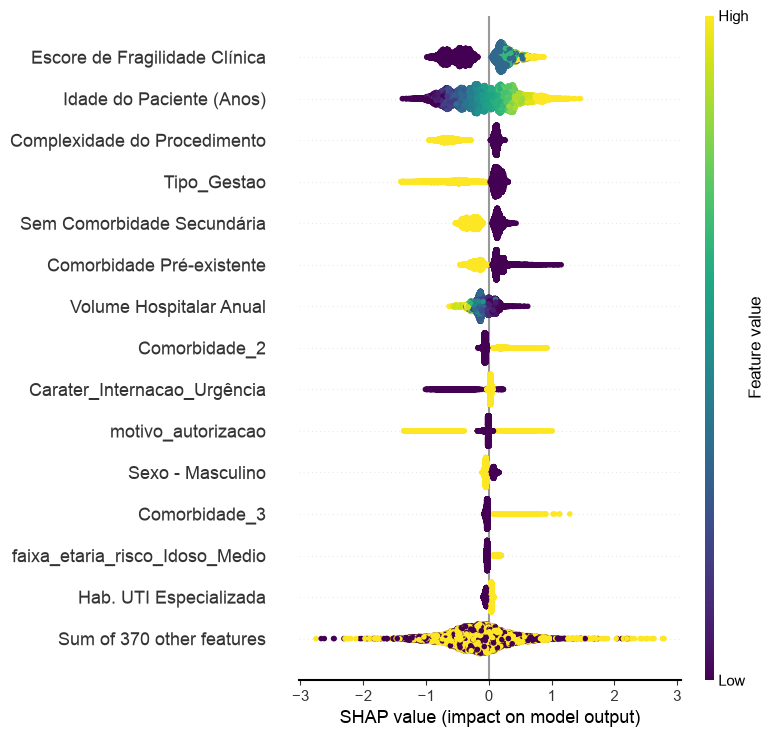

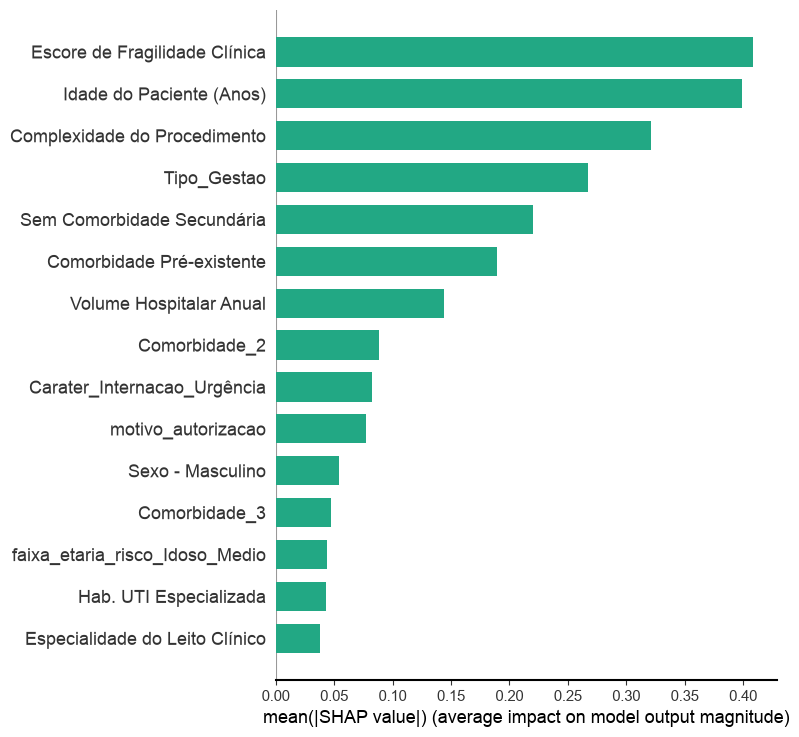

In [10]:
import shap
import matplotlib.pyplot as plt

print("Calculando SHAP values (pode levar alguns segundos)...")

explainer = shap.TreeExplainer(xgb_model)

# Mantendo exatamente sua amostra de 20000 registros para performance
X_shap = X_test.sample(20000, random_state=42)
shap_values = explainer.shap_values(X_shap)

# ============================================================
# PALETA VIRIDIS
# ============================================================
viridis = plt.colormaps["viridis"]

explanation = shap.Explanation(
    values=shap_values,
    data=X_shap.values,
    feature_names=X_shap.columns
)

# ============================================================
# SUMMARY PLOT — BEESWARM
# ============================================================
plt.figure(figsize=(10, 8))

shap.plots.beeswarm(
    explanation,
    max_display=15,
    color=viridis,
    show=False
)

ax = plt.gca()
ax.set_title('')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_plot.jpg', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# BAR PLOT — IMPORTÂNCIA MÉDIA ABSOLUTA
# ============================================================
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type='bar',
    max_display=15,
    show=False,
    color=viridis(0.60)
)

ax = plt.gca()
ax.set_title('')
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('../reports/figures/shap_bar_plot.jpg', dpi=300, bbox_inches='tight')
plt.show()


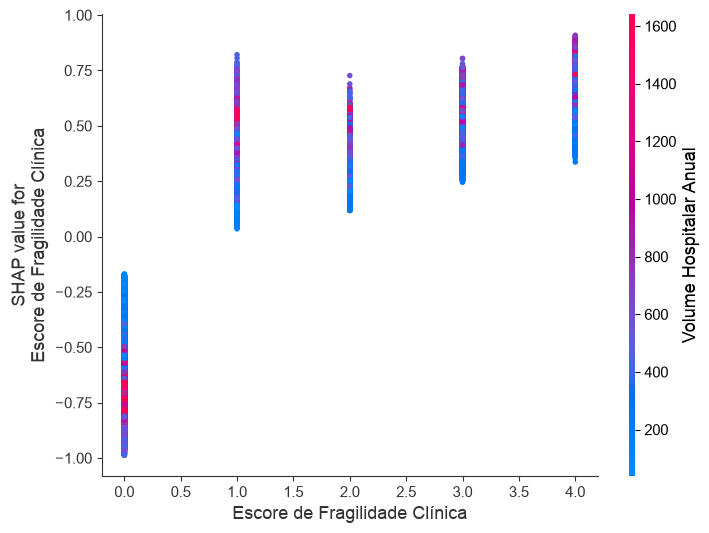

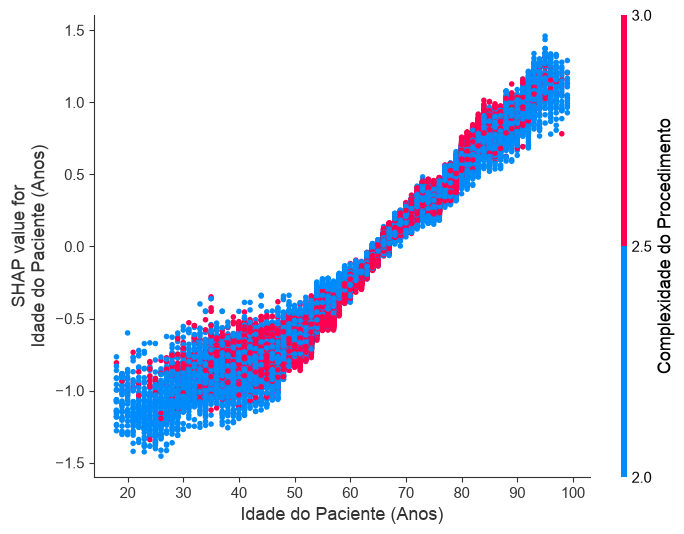

/tmp/ipykernel_1208363/2567705156.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  erro_por_idade = X_test_fairness.groupby('faixa_etaria')['erro_absoluto'].mean()


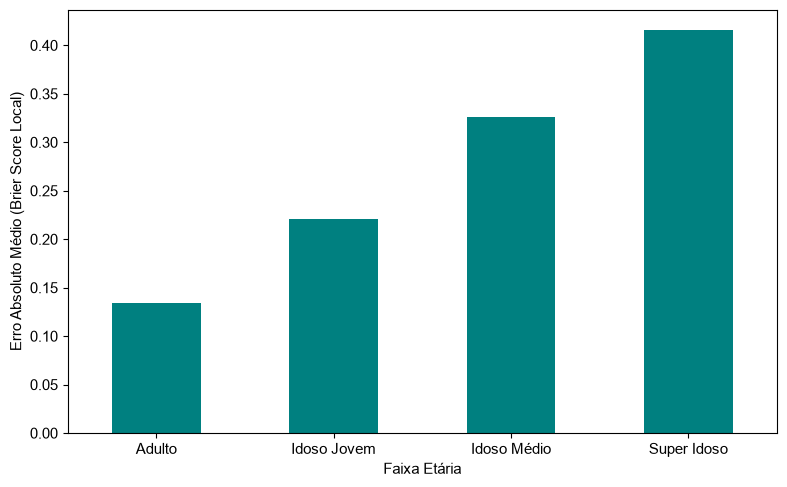

In [11]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

shap_values = explainer(X_test)

fig_dep, ax_dep = plt.subplots(figsize=(8, 6))
shap.dependence_plot(
    "Escore de Fragilidade Clínica", 
    shap_values.values, 
    X_test, 
    interaction_index="Volume Hospitalar Anual",
    ax=ax_dep,
    show=False
)
plt.savefig(FIG_PATH / 'shap_interaction_fragilidade_volume.jpg', dpi=300, bbox_inches='tight')
plt.show()

fig_dep2, ax_dep2 = plt.subplots(figsize=(8, 6))
shap.dependence_plot(
    "Idade do Paciente (Anos)", 
    shap_values.values, 
    X_test, 
    interaction_index="Complexidade do Procedimento",
    ax=ax_dep2,
    show=False
)
plt.savefig(FIG_PATH / 'shap_interaction_idade_complexidade.jpg', dpi=300, bbox_inches='tight')
plt.show()

X_test_fairness = X_test.copy()
X_test_fairness['faixa_etaria'] = pd.cut(X_test_fairness['Idade do Paciente (Anos)'], bins=[0, 59, 74, 84, 120], labels=['Adulto', 'Idoso Jovem', 'Idoso Médio', 'Super Idoso'])
X_test_fairness['erro_absoluto'] = np.abs(y_test - y_prob_xgb)

erro_por_idade = X_test_fairness.groupby('faixa_etaria')['erro_absoluto'].mean()

fig_fair, ax_fair = plt.subplots(figsize=(8, 5))
erro_por_idade.plot(kind='bar', color='teal', ax=ax_fair)
ax_fair.set_ylabel('Erro Absoluto Médio (Brier Score Local)')
ax_fair.set_xlabel('Faixa Etária')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_PATH / 'fairness_faixa_etaria.jpg', dpi=300, bbox_inches='tight')
plt.show()

## 6. Análise de Interação (Risco Clínico × Estrutura)

In [12]:
import numpy as np

# Cria dataframe com as predições de teste
df_interacao = pd.DataFrame({
    "obito_observado": y_test,
    "prob_predita": y_prob
})

# Cria os tercis de risco (Baixo, Médio, Alto Risco Clínico Previsto pelo ML)
df_interacao["tercil_risco"] = pd.qcut(df_interacao["prob_predita"], q=3, labels=["Baixo Risco", "Médio Risco", "Alto Risco"])

# Carrega a base enriquecida para recuperar o indicador de estrutura e risco
df_enriched = pd.read_csv("../data/processed/base_modelagem_enriched.csv", low_memory=False)

# Garantir que o index bate
if df_enriched.index.name != 'codigo_internacao':
    if 'codigo_internacao' in df_enriched.columns:
        df_enriched.set_index('codigo_internacao', inplace=True)
    else:
        df_enriched.index = df.index

# Associa a categoria de estrutura à nossa base de teste (mesmos índices)
idx_test = df_interacao.index
df_interacao["categoria_estrutura"] = df_enriched.loc[idx_test, "categoria_estrutura"].values

# Como definimos uma ordem lá no 03b, vamos reforçá-la aqui no Pandas
from pandas.api.types import CategoricalDtype
cat_type = CategoricalDtype(categories=["baixa", "média", "alta", "muito alta"], ordered=True)
df_interacao["categoria_estrutura"] = df_interacao["categoria_estrutura"].astype(cat_type)

tabela_interacao = df_interacao.groupby(["tercil_risco", "categoria_estrutura"])["obito_observado"].mean().reset_index()
tabela_interacao["obito_observado"] = tabela_interacao["obito_observado"] * 100

display(tabela_interacao.pivot(index="tercil_risco", columns="categoria_estrutura", values="obito_observado").round(2))


/tmp/ipykernel_1208363/4135364452.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabela_interacao = df_interacao.groupby(["tercil_risco", "categoria_estrutura"])["obito_observado"].mean().reset_index()


categoria_estrutura,baixa,média,alta,muito alta
tercil_risco,,,,
Baixo Risco,2.04,0.84,1.09,1.96
Médio Risco,6.91,5.12,4.66,5.44
Alto Risco,13.74,13.71,17.83,19.69


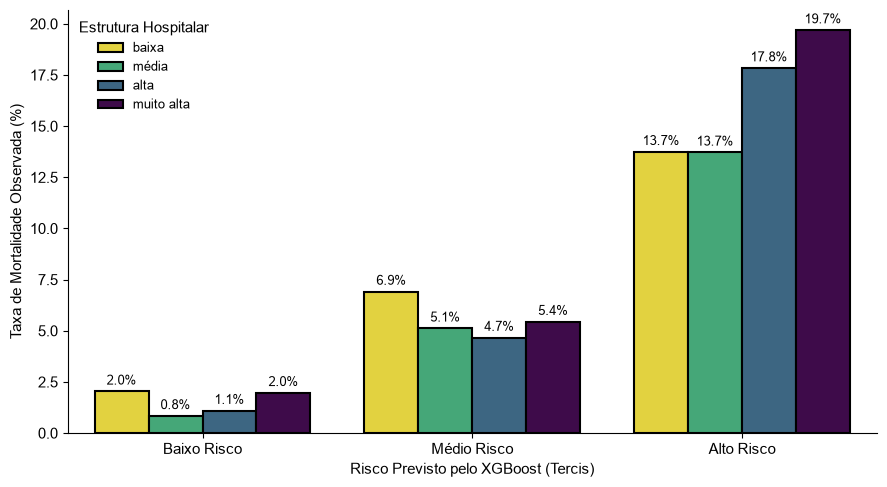

Figura salva: interacao_risco_estrutura.jpg


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

estrutura_ordem = [
    "baixa",
    "média",
    "alta",
    "muito alta"
]

cores_est = {
    "baixa": "#fde725",
    "média": "#35b779",
    "alta": "#31688e",
    "muito alta": "#440154"
}

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=tabela_interacao,
    x="tercil_risco",
    y="obito_observado",
    hue="categoria_estrutura",
    palette=cores_est,
    order=[
        "Baixo Risco",
        "Médio Risco",
        "Alto Risco"
    ],
    hue_order=estrutura_ordem,
    edgecolor="black",
    linewidth=1.5,
    ax=ax
)

ax.set_ylabel(
    "Taxa de Mortalidade Observada (%)"
)

ax.set_xlabel(
    "Risco Previsto pelo XGBoost (Tercis)"
)

ax.legend(
    title="Estrutura Hospitalar",
    frameon=False,
    loc="upper left",
    fontsize=9
)

ax.set_title('')
ax.grid(False)

for p in ax.patches:

    if p.get_height() > 0:

        ax.annotate(
            f"{p.get_height():.1f}%",
            (
                p.get_x() + p.get_width() / 2.,
                p.get_height()
            ),
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.tight_layout()

enforce_tcc_style()

plt.savefig(
    FIG_PATH / "interacao_risco_estrutura.jpg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura salva: interacao_risco_estrutura.jpg")

In [14]:
from statsmodels.stats.proportion import proportion_confint
import pandas as pd
import numpy as np

# Garante que df_interacao e categoria_estrutura estão disponíveis
# (executar após célula 25 — df_interacao já inclui tercil_risco e categoria_estrutura)

tercil_order   = ['Baixo Risco', 'Médio Risco', 'Alto Risco']
estrutura_cols = [c for c in df_interacao['categoria_estrutura'].unique()]

rows = []
for terc in tercil_order:
    for est in sorted(df_interacao['categoria_estrutura'].unique()):
        mask = (
            (df_interacao['tercil_risco'] == terc) &
            (df_interacao['categoria_estrutura'] == est)
        )
        n = int(mask.sum())
        if n == 0:
            continue
        k   = int(df_interacao.loc[mask, 'obito_observado'].sum())
        p   = k / n
        lo, hi = proportion_confint(k, n, alpha=0.05, method='wilson')
        estavel = '✅ OK' if n >= 200 else ('⚠️ pequeno' if n >= 50 else '🔴 instável')
        rows.append({
            'Tercil de Risco':       terc,
            'Estrutura Hospitalar':  est,
            'N':                     n,
            'Óbitos':                k,
            'Taxa de Mortalidade %': round(p * 100, 2),
            'IC 95% Inferior %':    round(lo * 100, 2),
            'IC 95% Superior %':    round(hi * 100, 2),
            'Estabilidade':         estavel
        })

df_ic = pd.DataFrame(rows)
display(df_ic.to_string(index=False))
print(f"\nMenor N em qualquer célula: {df_ic['N'].min():,}")
print("Todas as células com N >= 200 são estatisticamente estáveis.")

'Tercil de Risco Estrutura Hospitalar     N  Óbitos  Taxa de Mortalidade %  IC 95% Inferior %  IC 95% Superior % Estabilidade\n    Baixo Risco                 alta 32975     360                   1.09               0.99               1.21         ✅ OK\n    Baixo Risco                baixa   835      17                   2.04               1.27               3.24         ✅ OK\n    Baixo Risco           muito alta 10234     201                   1.96               1.71               2.25         ✅ OK\n    Baixo Risco                média  1916      16                   0.84               0.51               1.35         ✅ OK\n    Médio Risco                 alta 32595    1520                   4.66               4.44               4.90         ✅ OK\n    Médio Risco                baixa  2242     155                   6.91               5.94               8.04         ✅ OK\n    Médio Risco           muito alta  8915     485                   5.44               4.99               5.93      


Menor N em qualquer célula: 835
Todas as células com N >= 200 são estatisticamente estáveis.


In [15]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2 as chi2_dist
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ── Teste 1: Qui-quadrado ──────────────────────────────────────────────────────
df_interacao['grupo_celula'] = (
    df_interacao['tercil_risco'].astype(str) + ' × ' +
    df_interacao['categoria_estrutura'].astype(str)
)
contingency = pd.crosstab(df_interacao['grupo_celula'], df_interacao['obito_observado'])
contingency.columns = ['Alta (não óbito)', 'Óbito']

chi2_stat, p_chi2, dof_chi2, expected = chi2_contingency(contingency)

print("=" * 70)
print("TESTE 1 — Qui-quadrado de Pearson (independência grupo × desfecho)")
print("=" * 70)
print(f"  χ²({dof_chi2}) = {chi2_stat:.4f}")
print(f"  p-valor      = {p_chi2:.2e}")
sig1 = '*** p < 0,001' if p_chi2 < 0.001 else ('* p < 0,05' if p_chi2 < 0.05 else 'Não significativo')
print(f"  Resultado    = {sig1}")
print()
print("  Interpretação: testa se a distribuição de óbitos difere entre os grupos.")
print("  Note: este teste captura também o efeito principal do tercil (risco), que")
print("  é muito forte. O Teste 2 isola a modificação de efeito pela estrutura.")

# ── Teste 2: LR Test do termo de interação ─────────────────────────────────────
print()
print("=" * 70)
print("TESTE 2 — Regressão Logística: LR Test do termo de interação")
print("         tercil_risco × estrutura_hospitalar")
print("=" * 70)

df_reg = df_interacao.copy()
df_reg['tercil_risco']            = df_reg['tercil_risco'].astype('category')
df_reg['categoria_estrutura'] = df_reg['categoria_estrutura'].astype('category')

m_full = smf.logit(
    'obito_observado ~ C(tercil_risco) + C(categoria_estrutura)'
    ' + C(tercil_risco):C(categoria_estrutura)',
    data=df_reg
).fit(disp=0)

m_base = smf.logit(
    'obito_observado ~ C(tercil_risco) + C(categoria_estrutura)',
    data=df_reg
).fit(disp=0)

lr_stat = 2 * (m_full.llf - m_base.llf)
lr_dof  = m_full.df_model - m_base.df_model
lr_p    = chi2_dist.sf(lr_stat, lr_dof)

print(f"  Modelo sem interação   → LogL = {m_base.llf:.2f}")
print(f"  Modelo com interação   → LogL = {m_full.llf:.2f}")
print(f"  LR χ²({int(lr_dof)}) = {lr_stat:.4f}")
print(f"  p-valor    = {lr_p:.2e}")
sig2 = '*** p < 0,001' if lr_p < 0.001 else ('* p < 0,05' if lr_p < 0.05 else 'Não significativo (p > 0,05)')
print(f"  Resultado  = {sig2}")
print()
print("  Interpretação: o LR Test avalia se adicionar o termo de interação")
print("  melhora significativamente o ajuste do modelo. Se p > 0,05, o efeito")
print("  da estrutura hospitalar sobre a mortalidade é ADITIVO/UNIFORME nos")
print("  três tercis — não há modificação diferencial de efeito.")
print()
print("  → Para o TCC: reporte o qui-quadrado (Teste 1) para a diferença entre")
print("    grupos e contextualize o Teste 2 para precisão metodológica.")

TESTE 1 — Qui-quadrado de Pearson (independência grupo × desfecho)
  χ²(11) = 9529.4578
  p-valor      = 0.00e+00
  Resultado    = *** p < 0,001

  Interpretação: testa se a distribuição de óbitos difere entre os grupos.
  Note: este teste captura também o efeito principal do tercil (risco), que
  é muito forte. O Teste 2 isola a modificação de efeito pela estrutura.

TESTE 2 — Regressão Logística: LR Test do termo de interação
         tercil_risco × estrutura_hospitalar
  Modelo sem interação   → LogL = -33702.91
  Modelo com interação   → LogL = -33663.67
  LR χ²(6) = 78.4691
  p-valor    = 7.40e-15
  Resultado  = *** p < 0,001

  Interpretação: o LR Test avalia se adicionar o termo de interação
  melhora significativamente o ajuste do modelo. Se p > 0,05, o efeito
  da estrutura hospitalar sobre a mortalidade é ADITIVO/UNIFORME nos
  três tercis — não há modificação diferencial de efeito.

  → Para o TCC: reporte o qui-quadrado (Teste 1) para a diferença entre
    grupos e contextu

## 7. SHAP Fairness (Equidade Algorítmica)

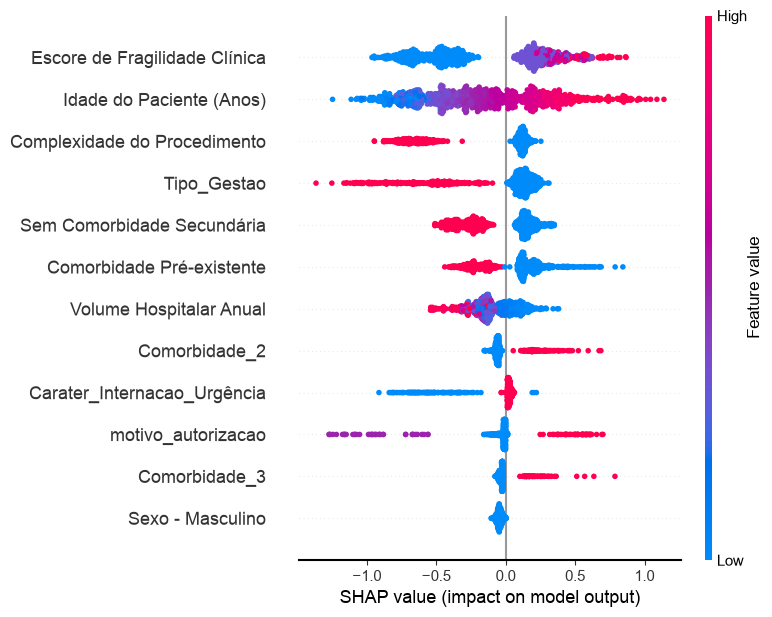

Figura salva: shap_fairness_masculino.jpg


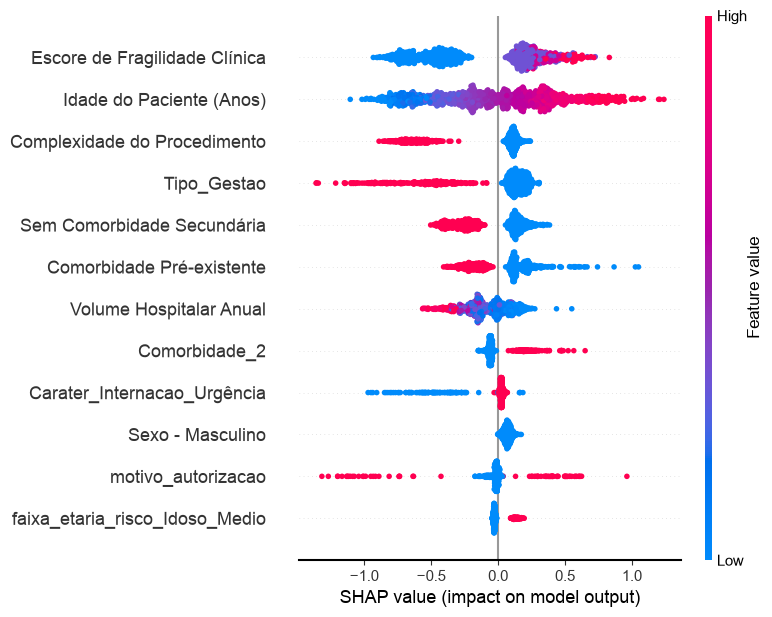

Figura salva: shap_fairness_feminino.jpg


In [16]:
import shap
import matplotlib.pyplot as plt

df_interacao["sexo"] = df_enriched.loc[idx_test, "sexo"].values

idx_masc = df_interacao["sexo"] == "Masculino"
idx_fem  = df_interacao["sexo"] == "Feminino"

explainer = shap.TreeExplainer(xgb_model)

X_test_masc = X_test.loc[idx_masc].sample(min(1000, idx_masc.sum()), random_state=42)
X_test_fem  = X_test.loc[idx_fem ].sample(min(1000, idx_fem.sum()),  random_state=42)

shap_masc = explainer.shap_values(X_test_masc)
shap_fem  = explainer.shap_values(X_test_fem)

def save_shap_fig(shap_vals, X_data, filename):
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, X_data, max_display=12, show=False)
    # TÍTULO REMOVIDO — norma TCC
    ax_s = plt.gcf().axes[0]
    ax_s.set_title('')
    ax_s.grid(False)
    ax_s.spines['top'].set_visible(False)
    ax_s.spines['right'].set_visible(False)
    ax_s.spines['bottom'].set_linewidth(1.5)
    ax_s.spines['left'].set_linewidth(1.5)
    plt.tight_layout()
    plt.savefig(FIG_PATH / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figura salva: {filename}')

# ── Masculino ─────────────────────────────────────────────────────────────────
save_shap_fig(shap_masc, X_test_masc, 'shap_fairness_masculino.jpg')

# ── Feminino ──────────────────────────────────────────────────────────────────
save_shap_fig(shap_fem, X_test_fem, 'shap_fairness_feminino.jpg')


Usando coluna: raca_cor

Distribuição (N >= 50 incluídos):
raca_cor
Branca            84686
Parda             43971
Preta              7486
Amarela            1361
Sem informação      354
Indígena             22

Grupos incluídos: ['Branca', 'Parda', 'Preta', 'Amarela', 'Sem informação']


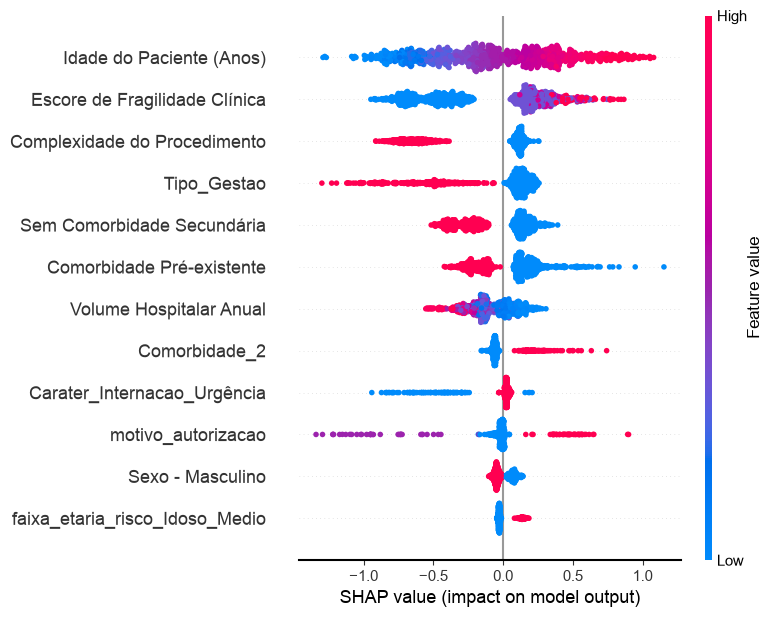

Figura salva: shap_fairness_raca_branca.jpg


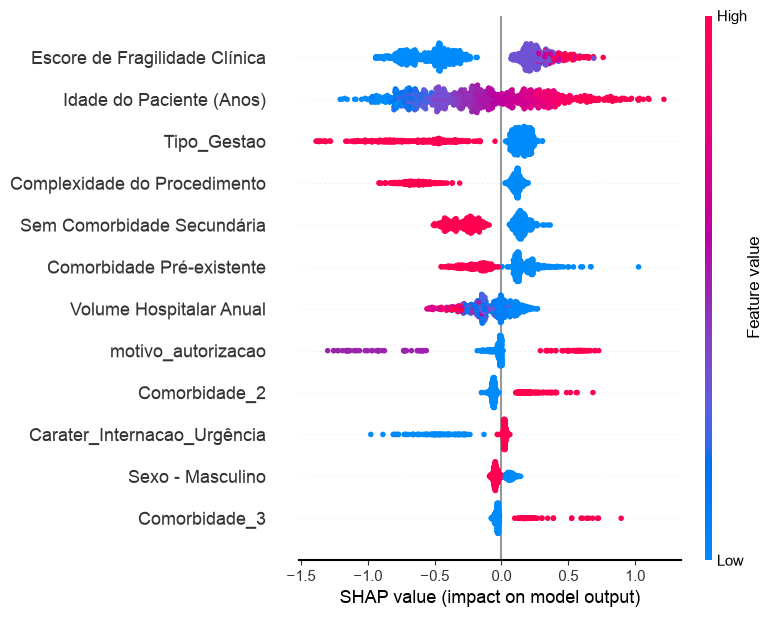

Figura salva: shap_fairness_raca_parda.jpg


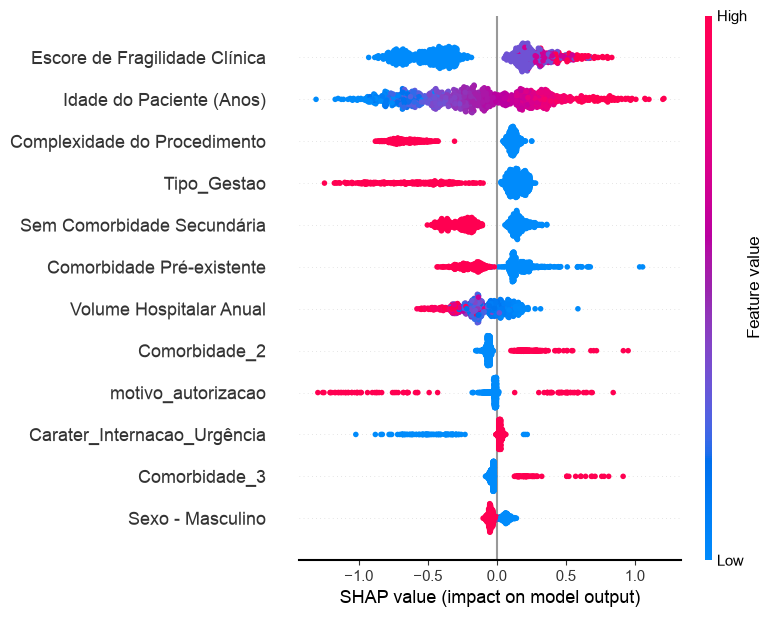

Figura salva: shap_fairness_raca_preta.jpg


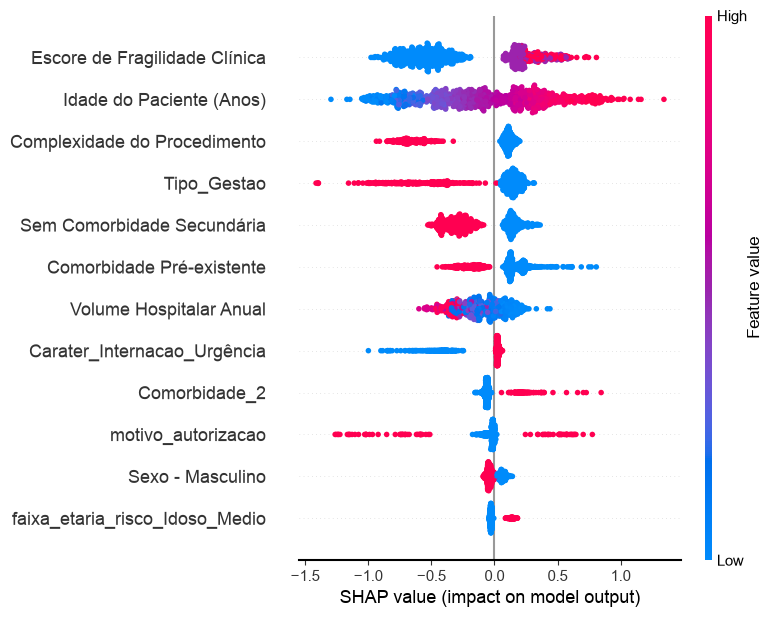

Figura salva: shap_fairness_raca_amarela.jpg


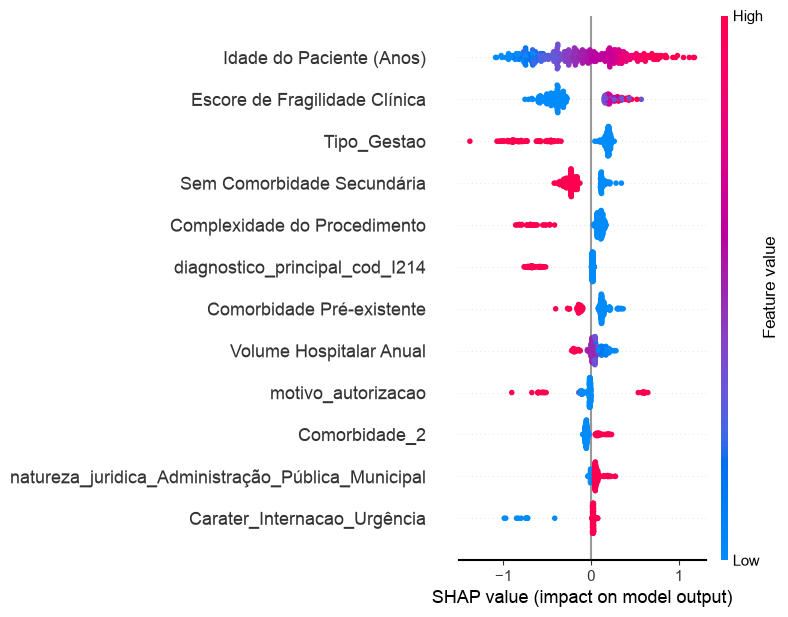

Figura salva: shap_fairness_raca_sem_informação.jpg

Interpretação: compare os top-12 preditores entre grupos.
Divergências acentuadas de ordem ou direção indicam possível viés.


In [17]:
import shap
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ── Identificar coluna de raça/cor ────────────────────────────────────────────
raca_col = next(
    (c for c in df_enriched.columns
     if ('ra' in c.lower() and 'cor' in c.lower()) or 'raca' in c.lower()),
    None
)

def save_shap_fig(shap_vals, X_data, filename):
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, X_data, max_display=12, show=False)
    # TÍTULO REMOVIDO — norma TCC
    ax_s = plt.gcf().axes[0]
    ax_s.set_title('')
    ax_s.grid(False)
    ax_s.spines['top'].set_visible(False)
    ax_s.spines['right'].set_visible(False)
    ax_s.spines['bottom'].set_linewidth(1.5)
    ax_s.spines['left'].set_linewidth(1.5)
    plt.tight_layout()
    plt.savefig(FIG_PATH / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figura salva: {filename}')

if raca_col is None:
    print('⚠️  Coluna de raça/cor não encontrada em df_enriched.')
    print('Colunas disponíveis:', [c for c in df_enriched.columns if len(c) < 25][:30])
else:
    print(f'Usando coluna: {raca_col}')
    df_interacao['raca_cor'] = df_enriched.loc[idx_test, raca_col].values

    contagem = df_interacao['raca_cor'].value_counts()
    grupos_validos = contagem[contagem >= 50].index.tolist()
    print(f'\nDistribuição (N >= 50 incluídos):')
    print(contagem.to_string())
    print(f'\nGrupos incluídos: {grupos_validos}')

    if len(grupos_validos) < 2:
        print('⚠️  Menos de 2 grupos com volume suficiente.')
    else:
        explainer = shap.TreeExplainer(xgb_model)
        for grupo in grupos_validos:
            idx_grupo = df_interacao['raca_cor'] == grupo
            n_sample  = min(1000, int(idx_grupo.sum()))
            X_grupo   = X_test.loc[idx_grupo].sample(n_sample, random_state=42)
            shap_grupo = explainer.shap_values(X_grupo)
            nome_arquivo = grupo.lower().replace('/', '_').replace(' ', '_')
            save_shap_fig(shap_grupo, X_grupo, f'shap_fairness_raca_{nome_arquivo}.jpg')

        print('\nInterpretação: compare os top-12 preditores entre grupos.')
        print('Divergências acentuadas de ordem ou direção indicam possível viés.')
